In [3]:
import numpy as np
import pandas as pd
import scanpy as sc
import snapatac2 as snap
import pickle
import sys
from tqdm import tqdm

import matplotlib.pyplot as plt
import seaborn as sns

from captum.attr import InputXGradient

import warnings
import os
import glob

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica']
plt.rcParams['font.size'] = 12
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['pdf.fonttype'] = 42

In [4]:
fold_dirs = [f.path for f in os.scandir('/data1/normantm/eli/T7/202511_RPE1_dg50/models/genelevel_clustered/folds_ln') if f.name.startswith('fold')]
test_dfs = [pd.read_csv(os.path.join(fold_dir, 'test_preds.csv'), index_col = 0) for fold_dir in fold_dirs if os.path.exists(os.path.join(fold_dir, 'test_preds.csv'))]
test_preds = pd.concat(test_dfs, axis = 0)
test_preds['is_single'] = test_preds.guide_target.map(lambda g: g.split("_")[0] == g.split("_")[1])
program_features = pd.read_csv("/data1/normantm/eli/T7/202511_RPE1_dg50/analysis/intermediate_files/260414_gex_raw_100_prgm_features.csv")
test_preds['is_prgm'] = test_preds.gene.isin(program_features.feature.unique())

test_preds.query("not is_single").filter(like = 'resid').corr()

,resid,pred_resid,peak_ablated_pred_resid,expr_ablated_pred_resid,chromvar_ablated_pred_resid
resid,1.000000,0.484251,0.443481,0.089497,0.065157
pred_resid,0.484251,1.000000,0.896620,0.191742,0.162867
peak_ablated_pred_resid,0.443481,0.896620,1.000000,0.168287,0.123080
expr_ablated_pred_resid,0.089497,0.191742,0.168287,1.000000,0.034224
chromvar_ablated_pred_resid,0.065157,0.162867,0.123080,0.034224,1.000000


In [24]:
baselines = pd.read_csv("/data1/normantm/eli/T7/202511_RPE1_dg50/models/genelevel_clustered/fold_baseline_performance.csv", index_col=0)
baselines_plot = baselines.reset_index()[['index', 'linear_pearson', 'nonlinear_pearson']].melt(id_vars='index', var_name='method', value_name='performance')
baselines_plot['method'] = baselines_plot.method.str.split('_').str[0]
baselines_plot['method'] = baselines_plot.method.replace('linear', 'bilinear')
fold_dirs = sorted([f.path for f in os.scandir('/data1/normantm/eli/T7/202511_RPE1_dg50/models/genelevel_clustered/folds_ln')])
df_folds = pd.DataFrame(columns = ['index', 'method', 'performance'])
for fold_dir in fold_dirs:
    if os.path.exists(os.path.join(fold_dir, 'test_preds.csv')):
        fold = fold_dir.split('fold')[-1].split('_')[0]
        preds = pd.read_csv(os.path.join(fold_dir, 'test_preds.csv'))
        preds['is_single'] = preds.guide_target.map(lambda g: g.split("_")[0] == g.split("_")[1])
        corr = preds.query("not is_single")[['resid', 'pred_resid']].corr().iloc[0,1]
        df_folds.loc[fold] = [fold, 'deep', corr]
    else:
        continue

df_folds.index = df_folds.index.astype(int)
baselines_plot = pd.concat([baselines_plot, df_folds], axis=0)
baselines_plot['method'] = baselines_plot.method.map({"bilinear": "Bilinear", 'nonlinear': 'Simple nonlinear', 'deep': 'Transformer'})
baselines_plot

,index,method,performance
0,1,Bilinear,0.272412
1,2,Bilinear,0.272976
2,3,Bilinear,0.267192
3,4,Bilinear,0.286132
4,5,Bilinear,0.280938
5,6,Bilinear,0.259363
6,7,Bilinear,0.258785
7,8,Bilinear,0.255631
8,9,Bilinear,0.292389
9,10,Bilinear,0.272904


2026-07-09 11:30:08 - INFO - maxp pruned
2026-07-09 11:30:08 - INFO - cmap pruned
2026-07-09 11:30:08 - INFO - post pruned
2026-07-09 11:30:08 - INFO - FFTM dropped
2026-07-09 11:30:08 - INFO - GPOS pruned
2026-07-09 11:30:08 - INFO - GSUB pruned
2026-07-09 11:30:08 - INFO - glyf pruned
2026-07-09 11:30:08 - INFO - Added gid0 to subset
2026-07-09 11:30:08 - INFO - Added first four glyphs to subset
2026-07-09 11:30:08 - INFO - Closing glyph list over 'GSUB': 35 glyphs before
2026-07-09 11:30:08 - INFO - Glyph names: ['.notdef', '.null', 'B', 'M', 'P', 'S', 'T', 'a', 'c', 'd', 'e', 'f', 'five', 'four', 'g', 'i', 'l', 'm', 'n', 'nonmarkingreturn', 'o', 'one', 'p', 'parenleft', 'parenright', 'period', 'r', 's', 'space', 't', 'three', 'two', 'uni0008', 'y', 'zero']
2026-07-09 11:30:08 - INFO - Glyph IDs:   [0, 1, 2, 3, 5, 13, 14, 19, 21, 22, 23, 24, 25, 26, 39, 50, 53, 56, 57, 70, 72, 73, 74, 75, 76, 78, 81, 82, 83, 84, 85, 87, 88, 89, 94]
2026-07-09 11:30:08 - INFO - Closed glyph list over

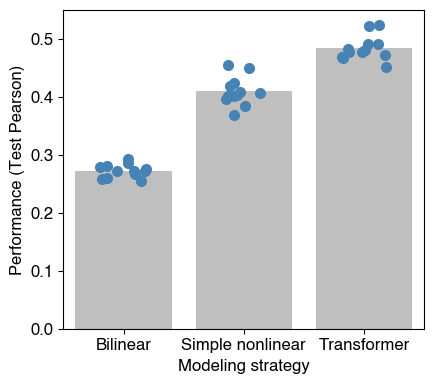

In [57]:
np.random.seed(42)
plt.figure(figsize = (4.5,4))
sns.stripplot(data=baselines_plot, x='method', y='performance', dodge=False, jitter=0.2, color = 'steelblue', linewidth=0, edgecolor=None, legend = None, size = 8)
sns.barplot(data=baselines_plot, x='method', y='performance', color = '#bfbfbf', errorbar = None, estimator=np.mean)
plt.xlabel('Modeling strategy')
plt.ylabel("Performance (Test Pearson)")
plt.tight_layout()
plt.savefig("plots/Sxc_performance_baselines.pdf")
plt.show()

In [49]:
fold_dirs = sorted([f.path for f in os.scandir('/data1/normantm/eli/T7/202511_RPE1_dg50/models/genelevel_clustered/folds_ln')])
df_folds = pd.DataFrame(columns = ['real', 'Peak\nfeatures', 'Singles\nexpression', 'ChromVAR'])
for fold_dir in fold_dirs:
    if os.path.exists(os.path.join(fold_dir, 'test_preds.csv')):
        fold = fold_dir.split('fold')[-1].split('_')[0]
        preds = pd.read_csv(os.path.join(fold_dir, 'test_preds.csv'))
        preds['is_single'] = preds.guide_target.map(lambda g: g.split("_")[0] == g.split("_")[1])
        cmtx = preds.query("not is_single").filter(like = 'resid').corr()
        df_folds.loc[fold] = [cmtx.loc['resid', 'pred_resid'], cmtx.loc['resid', 'peak_ablated_pred_resid'], cmtx.loc['resid', 'expr_ablated_pred_resid'], cmtx.loc['resid', 'chromvar_ablated_pred_resid']]
    else:
        continue

df_folds_subtracted = 100 * (df_folds - df_folds['real'].values[:, np.newaxis]) / df_folds['real'].values[:, np.newaxis]

2026-07-09 11:30:18 - INFO - maxp pruned
2026-07-09 11:30:18 - INFO - cmap pruned
2026-07-09 11:30:18 - INFO - post pruned
2026-07-09 11:30:18 - INFO - FFTM dropped
2026-07-09 11:30:18 - INFO - GPOS pruned
2026-07-09 11:30:18 - INFO - GSUB pruned
2026-07-09 11:30:18 - INFO - glyf pruned
2026-07-09 11:30:18 - INFO - Added gid0 to subset
2026-07-09 11:30:18 - INFO - Added first four glyphs to subset
2026-07-09 11:30:18 - INFO - Closing glyph list over 'GSUB': 42 glyphs before
2026-07-09 11:30:18 - INFO - Glyph names: ['.notdef', '.null', 'A', 'C', 'P', 'R', 'S', 'T', 'V', 'a', 'b', 'c', 'd', 'e', 'eight', 'f', 'four', 'g', 'h', 'hyphen', 'i', 'k', 'l', 'm', 'n', 'nonmarkingreturn', 'o', 'p', 'parenleft', 'parenright', 'percent', 'r', 's', 'six', 'space', 't', 'two', 'u', 'uni0008', 'v', 'x', 'zero']
2026-07-09 11:30:18 - INFO - Glyph IDs:   [0, 1, 2, 3, 5, 10, 13, 14, 18, 21, 23, 25, 27, 29, 38, 40, 53, 55, 56, 57, 59, 70, 71, 72, 73, 74, 75, 76, 77, 78, 80, 81, 82, 83, 84, 85, 87, 88, 8

2026-07-09 11:30:18 - INFO - Closed glyph list over 'glyf': 44 glyphs after
2026-07-09 11:30:18 - INFO - Glyph names: ['.notdef', '.null', 'A', 'C', 'P', 'R', 'S', 'T', 'V', 'a', 'b', 'c', 'd', 'e', 'eight', 'f', 'four', 'g', 'h', 'hyphen', 'i', 'k', 'l', 'm', 'n', 'nonmarkingreturn', 'o', 'p', 'parenleft', 'parenright', 'percent', 'r', 's', 'six', 'space', 't', 'two', 'u', 'uni0008', 'uniFB01', 'uniFB02', 'v', 'x', 'zero']
2026-07-09 11:30:18 - INFO - Glyph IDs:   [0, 1, 2, 3, 5, 10, 13, 14, 18, 21, 23, 25, 27, 29, 38, 40, 53, 55, 56, 57, 59, 70, 71, 72, 73, 74, 75, 76, 77, 78, 80, 81, 82, 83, 84, 85, 87, 88, 89, 90, 91, 93, 231, 232]
2026-07-09 11:30:18 - INFO - Retaining 44 glyphs
2026-07-09 11:30:18 - INFO - head subsetting not needed
2026-07-09 11:30:18 - INFO - hhea subsetting not needed
2026-07-09 11:30:18 - INFO - maxp subsetting not needed
2026-07-09 11:30:18 - INFO - OS/2 subsetting not needed
2026-07-09 11:30:18 - INFO - hmtx subsetted
2026-07-09 11:30:18 - INFO - cmap subse

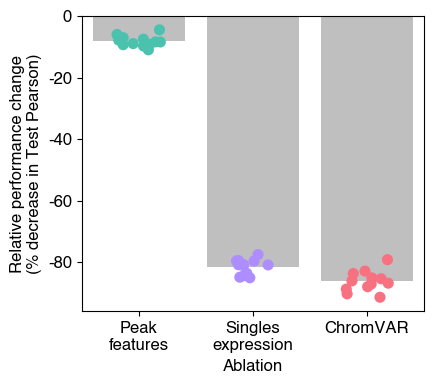

In [58]:
df_plot = df_folds_subtracted.drop('real', axis = 1).melt(var_name = 'ablation', value_name = 'performance_delta')
np.random.seed(42)
plt.figure(figsize = (4.5,4))
sns.stripplot(data=df_plot, x='ablation', y='performance_delta', dodge=False, jitter=0.2, linewidth=0, edgecolor=None, legend = None, size = 8, palette = ['#4bc2ad', '#ae8eff', '#f77181'], hue = 'ablation')
sns.barplot(data=df_plot, x='ablation', y='performance_delta', color = '#bfbfbf', errorbar = None, estimator=np.mean)
plt.xlabel('Ablation')
plt.ylabel("Relative performance change\n(% decrease in Test Pearson)")
plt.tight_layout()
plt.savefig("plots/Sxd_ablation.pdf")
plt.show()